In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [3]:
df = pd.read_csv("/Users/bhavyakansal/Downloads/Crop.csv")

df.head()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B,label
0,143,69,217,5.9,0.58,0.23,10.20,116.35,59.96,54.85,21.29,pomegranate
1,170,36,216,5.9,0.15,0.28,15.69,114.20,56.87,31.28,28.62,pomegranate
2,158,66,219,6.8,0.34,0.20,15.29,65.87,51.81,57.12,27.59,pomegranate
3,133,45,207,6.4,0.94,0.21,8.48,103.10,43.81,68.50,47.29,pomegranate
4,132,48,218,6.7,0.54,0.19,5.59,63.40,56.40,46.71,31.04,pomegranate


In [4]:
df.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000,620.000000
mean,135.701613,52.508065,161.401613,6.106290,0.885468,0.484085,17.315452,117.212500,219.905887,34.340839,28.750710
std,31.808083,24.673538,81.285780,0.693782,0.637214,5.775388,6.441150,62.775199,341.998793,11.543871,19.636447
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,89.000000,5.700000,0.297500,0.086000,12.592500,68.312500,58.785000,24.727500,13.442500
50%,138.000000,54.000000,157.500000,6.100000,0.780000,0.168000,16.910000,108.245000,73.580000,31.425000,23.225000
75%,160.000000,75.000000,206.000000,6.500000,1.390000,0.240000,21.102500,155.620000,163.665000,43.542500,42.767500
max,198.000000,100.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.560000


# Separate Features and Target

In [5]:
features = df.drop('label', axis=1)
target = df['label']

# or

In [7]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

In [8]:
X

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
0,143,69,217,5.9,0.58,0.23000,10.20,116.35,59.96,54.85,21.29
1,170,36,216,5.9,0.15,0.28000,15.69,114.20,56.87,31.28,28.62
2,158,66,219,6.8,0.34,0.20000,15.29,65.87,51.81,57.12,27.59
3,133,45,207,6.4,0.94,0.21000,8.48,103.10,43.81,68.50,47.29
4,132,48,218,6.7,0.54,0.19000,5.59,63.40,56.40,46.71,31.04
...,...,...,...,...,...,...,...,...,...,...,...
615,41,23,135,5.0,1.67,0.10655,26.00,39.20,206.89,31.09,20.64
616,49,45,90,5.8,1.98,0.09229,19.00,40.20,91.12,32.68,14.91
617,131,24,121,4.9,2.24,0.08775,22.00,40.00,94.34,24.93,23.74
618,131,55,130,5.3,2.48,0.08983,15.00,41.00,92.58,45.73,21.48


In [9]:
y

0      pomegranate
1      pomegranate
2      pomegranate
3      pomegranate
4      pomegranate
          ...     
615         potato
616         potato
617         potato
618         potato
619         potato
Name: label, Length: 620, dtype: str

In [10]:
y.value_counts()

label
pomegranate    104
mango          104
grapes         104
mulberry       104
ragi           104
potato         100
Name: count, dtype: int64

# train-test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
X_train.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000,496.000000
mean,136.477823,52.500000,162.705645,6.114919,0.881794,0.565803,17.207460,118.600242,221.061008,34.457440,28.709355
std,31.688055,24.274607,81.627919,0.694407,0.628641,6.455623,6.447591,63.377239,344.385068,11.706243,19.783541
min,30.000000,10.000000,51.000000,4.500000,0.010000,0.011100,0.180000,3.810000,20.580000,17.990000,1.020000
25%,116.000000,30.000000,90.750000,5.700000,0.310000,0.087087,12.592500,69.125000,59.505000,25.032500,13.167500
50%,139.000000,53.000000,157.500000,6.100000,0.780000,0.167500,16.745000,108.945000,73.580000,31.230000,23.225000
75%,161.000000,74.250000,207.000000,6.500000,1.375000,0.240000,21.315000,157.287500,167.945000,43.542500,43.635000
max,198.000000,99.000000,369.000000,8.000000,2.480000,113.200000,35.000000,276.720000,1572.540000,70.000000,74.150000


In [13]:
X_test.describe()

,N,P,K,ph,EC,S,Cu,Fe,Mn,Zn,B
count,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000,124.000000
mean,132.596774,52.540323,156.185484,6.071774,0.900161,0.157211,17.747419,111.661532,215.285403,33.874435,28.916129
std,32.225809,26.311888,80.015585,0.693003,0.672864,0.094275,6.423124,60.235262,333.610014,10.903097,19.114269
min,33.000000,11.000000,52.000000,4.500000,0.030000,0.014200,5.480000,38.300000,22.040000,19.130000,1.640000
25%,117.500000,29.500000,82.000000,5.700000,0.255000,0.083305,12.652500,66.517500,55.965000,23.467500,14.712500
50%,135.500000,55.500000,154.500000,6.100000,0.790000,0.169000,17.595000,99.670000,73.935000,32.485000,23.275000
75%,154.000000,75.000000,201.250000,6.500000,1.407500,0.240500,21.042500,145.440000,157.812500,43.187500,39.217500
max,198.000000,100.000000,365.000000,7.800000,2.480000,0.330000,33.670000,260.730000,1532.580000,67.530000,74.560000


In [14]:
y_train.describe()

count      496
unique       6
top       ragi
freq        88
Name: label, dtype: object

In [15]:
y_test.describe()

count        124
unique         6
top       grapes
freq          24
Name: label, dtype: object

# Model Training

In [16]:
model = LogisticRegression()
model.fit(X_train, y_train)

/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)


print(f"Our Model Accuracy is: {accuracy * 100} %")

Our Model Accuracy is: 97.58064516129032 %


# Classification report

In [18]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

      grapes       0.96      0.96      0.96        24
       mango       0.94      0.94      0.94        18
    mulberry       1.00      1.00      1.00        21
 pomegranate       1.00      0.95      0.98        22
      potato       1.00      1.00      1.00        23
        ragi       0.94      1.00      0.97        16

    accuracy                           0.98       124
   macro avg       0.97      0.98      0.97       124
weighted avg       0.98      0.98      0.98       124



# Confusion Matrix 

In [19]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[23  0  0  0  0  1]
 [ 1 17  0  0  0  0]
 [ 0  0 21  0  0  0]
 [ 0  1  0 21  0  0]
 [ 0  0  0  0 23  0]
 [ 0  0  0  0  0 16]]


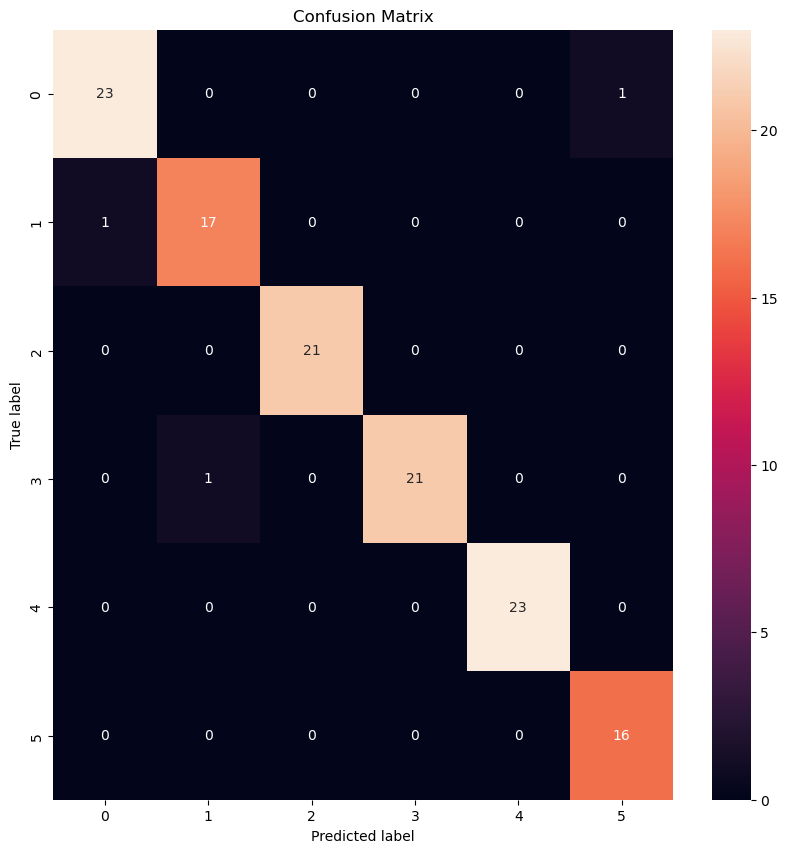

In [20]:
plt.figure(figsize=(10, 10))
sns.heatmap(cm, annot=True, fmt='g')
plt.title('Confusion Matrix')
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.show()


# Prediction Time

In [21]:
prediction = model.predict([[83,78,135,5,1.25,0.33,18.50,52.06,88.67,40.62,71.34]])

print(prediction[0])

mango


/opt/miniconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
